In [13]:
print("Logistic predictions:", "logreg_test_predictions" in globals())
print("SVM predictions:", "svm_test_predictions" in globals())

Logistic predictions: True
SVM predictions: True


In [12]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "BERT",
        "RoBERTa"
    ],
    "Accuracy": [
        0.8964,
        0.8962,
        0.9177,
        0.9323
    ],
    "Precision": [
        0.8912,
        0.8974,
        0.9116,
        0.9238
    ],
    "Recall": [
        0.9030,
        0.8947,
        0.9252,
        0.9424
    ],
    "F1": [
        0.8971,
        0.8960,
        0.9183,
        0.9330
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8964,0.8912,0.9030,0.8971
1,Linear SVM,0.8962,0.8974,0.8947,0.8960
2,BERT,0.9177,0.9116,0.9252,0.9183
3,RoBERTa,0.9323,0.9238,0.9424,0.9330


In [11]:
logreg_test_predictions = logreg_model.predict(X_test_tfidf)

logreg_test_accuracy = accuracy_score(
    test_df["label"],
    logreg_test_predictions
)

logreg_test_precision = precision_score(
    test_df["label"],
    logreg_test_predictions
)

logreg_test_recall = recall_score(
    test_df["label"],
    logreg_test_predictions
)

logreg_test_f1 = f1_score(
    test_df["label"],
    logreg_test_predictions
)

print("\n" + "=" * 55)
print("LOGISTIC REGRESSION — FINAL TEST RESULTS")
print("=" * 55)

print(f"Accuracy : {logreg_test_accuracy:.4f}")
print(f"Precision: {logreg_test_precision:.4f}")
print(f"Recall   : {logreg_test_recall:.4f}")
print(f"F1-score : {logreg_test_f1:.4f}")


LOGISTIC REGRESSION — FINAL TEST RESULTS
Accuracy : 0.8964
Precision: 0.8912
Recall   : 0.9030
F1-score : 0.8971


In [10]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg_model.fit(
    X_train_tfidf,
    train_df["label"]
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [9]:
svm_test_predictions = svm_model.predict(X_test_tfidf)

svm_test_accuracy = accuracy_score(
    test_df["label"],
    svm_test_predictions
)

svm_test_precision = precision_score(
    test_df["label"],
    svm_test_predictions
)

svm_test_recall = recall_score(
    test_df["label"],
    svm_test_predictions
)

svm_test_f1 = f1_score(
    test_df["label"],
    svm_test_predictions
)

print("\n" + "=" * 55)
print("LINEAR SVM — FINAL TEST RESULTS")
print("=" * 55)

print(f"Accuracy : {svm_test_accuracy:.4f}")
print(f"Precision: {svm_test_precision:.4f}")
print(f"Recall   : {svm_test_recall:.4f}")
print(f"F1-score : {svm_test_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_df["label"],
        svm_test_predictions
    )
)


LINEAR SVM — FINAL TEST RESULTS
Accuracy : 0.8962
Precision: 0.8974
Recall   : 0.8947
F1-score : 0.8960

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     12500
           1       0.90      0.89      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

svm_val_predictions = svm_model.predict(X_val_tfidf)

print("\n" + "=" * 50)
print("LINEAR SVM — VALIDATION")
print("=" * 50)

print(f"Accuracy : {accuracy_score(val_df['label'], svm_val_predictions):.4f}")
print(f"Precision: {precision_score(val_df['label'], svm_val_predictions):.4f}")
print(f"Recall   : {recall_score(val_df['label'], svm_val_predictions):.4f}")
print(f"F1-score : {f1_score(val_df['label'], svm_val_predictions):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        val_df["label"],
        svm_val_predictions
    )
)


LINEAR SVM — VALIDATION
Accuracy : 0.9064
Precision: 0.9023
Recall   : 0.9124
F1-score : 0.9073

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      2468
           1       0.90      0.91      0.91      2489

    accuracy                           0.91      4957
   macro avg       0.91      0.91      0.91      4957
weighted avg       0.91      0.91      0.91      4957



In [7]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    train_df["label"]
)

print("Linear SVM trained successfully.")

Linear SVM trained successfully.


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["text"])
X_val_tfidf = tfidf_vectorizer.transform(val_df["text"])
X_test_tfidf = tfidf_vectorizer.transform(test_df["text"])

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (19824, 50000)
Validation TF-IDF shape: (4957, 50000)
Test TF-IDF shape: (25000, 50000)


In [5]:
import pandas as pd

train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")
test_df = pd.read_csv("../data/processed/test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (19824, 2)
Validation: (4957, 2)
Test: (25000, 2)


FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [3]:
import pandas as pd
from pathlib import Path

print("Current folder:", Path.cwd())
print("Files:")
for f in Path.cwd().glob("*.csv"):
    print(" -", f.name)

Current folder: d:\Mitacs\transformer-text-classification\notebooks
Files:


In [2]:
print("train_df:", "train_df" in globals())
print("val_df:", "val_df" in globals())
print("test_df:", "test_df" in globals())

train_df: False
val_df: False
test_df: False


In [1]:
print("SVM model:", "svm_model" in globals())
print("TF-IDF vectorizer:", "tfidf_vectorizer" in globals())

SVM model: False
TF-IDF vectorizer: False


In [17]:
import os

os.makedirs("../data/processed", exist_ok=True)

train_clean_df[["text", "label"]].to_csv(
    "../data/processed/train.csv",
    index=False
)

val_df[["text", "label"]].to_csv(
    "../data/processed/validation.csv",
    index=False
)

test_df[["text", "label"]].to_csv(
    "../data/processed/test.csv",
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [16]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.13.0+cpu
CUDA available: False


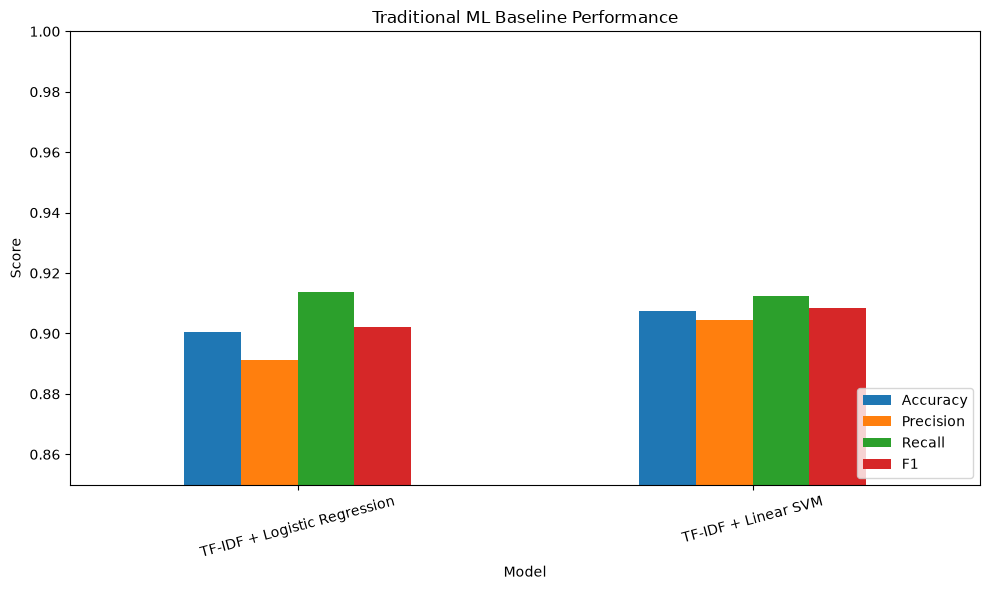

In [15]:
# ==========================================
# Traditional ML Baseline Performance
# ==========================================

import matplotlib.pyplot as plt

baseline_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Traditional ML Baseline Performance")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

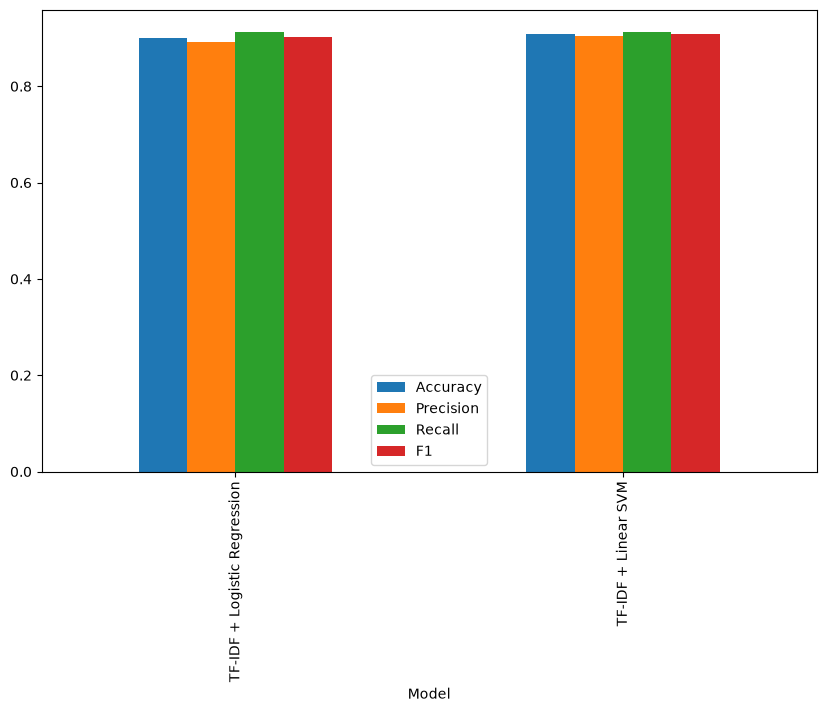

In [14]:
# ==========================================
# Baseline Performance Comparison
# ==========================================

baseline_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Traditional ML Baseline Performance")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [13]:
# ==========================================
# Traditional ML Baseline Comparison
# ==========================================

baseline_results = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Linear SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        svm_accuracy
    ],
    "Precision": [
        lr_precision,
        svm_precision
    ],
    "Recall": [
        lr_recall,
        svm_recall
    ],
    "F1": [
        lr_f1,
        svm_f1
    ]
})

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF + Logistic Regression,0.9005,0.8911,0.9136,0.9022
1,TF-IDF + Linear SVM,0.9076,0.9044,0.9124,0.9084


In [12]:
svm_accuracy = accuracy_score(y_val, svm_val_pred)
svm_precision = precision_score(y_val, svm_val_pred)
svm_recall = recall_score(y_val, svm_val_pred)
svm_f1 = f1_score(y_val, svm_val_pred)

print("Linear SVM — Validation")
print("=" * 45)
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-score : {svm_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, svm_val_pred))

Linear SVM — Validation
Accuracy : 0.9076
Precision: 0.9044
Recall   : 0.9124
F1-score : 0.9084

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      2468
           1       0.90      0.91      0.91      2489

    accuracy                           0.91      4957
   macro avg       0.91      0.91      0.91      4957
weighted avg       0.91      0.91      0.91      4957



In [11]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=SEED
)

svm_model.fit(X_train_tfidf, y_train)

svm_val_pred = svm_model.predict(X_val_tfidf)

print("Linear SVM training complete.")

Linear SVM training complete.


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

lr_accuracy = accuracy_score(y_val, lr_val_pred)
lr_precision = precision_score(y_val, lr_val_pred)
lr_recall = recall_score(y_val, lr_val_pred)
lr_f1 = f1_score(y_val, lr_val_pred)

print("Logistic Regression — Validation")
print("=" * 45)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-score : {lr_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, lr_val_pred))

Logistic Regression — Validation
Accuracy : 0.9005
Precision: 0.8911
Recall   : 0.9136
F1-score : 0.9022

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      2468
           1       0.89      0.91      0.90      2489

    accuracy                           0.90      4957
   macro avg       0.90      0.90      0.90      4957
weighted avg       0.90      0.90      0.90      4957



In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

lr_model.fit(X_train_tfidf, y_train)

lr_val_pred = lr_model.predict(X_val_tfidf)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [8]:
tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (19824, 50000)
Validation TF-IDF shape: (4957, 50000)
Test TF-IDF shape: (25000, 50000)


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [6]:
X_train = train_clean_df["text"]
y_train = train_clean_df["label"]

X_val = val_df["text"]
y_val = val_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

In [4]:
train_clean_df, val_df = train_test_split(
    clean_train_pool,
    test_size=0.20,
    random_state=SEED,
    stratify=clean_train_pool["label"]
)

print("Training:", len(train_clean_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Training: 19824
Validation: 4957
Test: 25000


In [3]:
# Identify reviews appearing in the official test set
test_review_set = set(test_df["text"])

# Remove train/test overlapping reviews
leakage_free_train = train_df[
    ~train_df["text"].isin(test_review_set)
].copy()

# Remove duplicate reviews within training data
clean_train_pool = leakage_free_train.drop_duplicates(
    subset="text",
    keep="first"
).copy()

print("Original training rows:", len(train_df))
print("After removing test overlaps:", len(leakage_free_train))
print("Final clean training pool:", len(clean_train_pool))
print("Remaining duplicates:", clean_train_pool["text"].duplicated().sum())

Original training rows: 25000
After removing test overlaps: 24877
Final clean training pool: 24781
Remaining duplicates: 0


In [2]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np

SEED = 42

dataset = load_dataset("stanfordnlp/imdb")

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Original train:", len(train_df))
print("Original test:", len(test_df))

Original train: 25000
Original test: 25000


# Traditional Machine Learning Baselines

This notebook establishes traditional machine learning baselines for IMDb sentiment classification.

## Models
1. TF-IDF + Logistic Regression
2. TF-IDF + Linear SVM

The models are trained on the leakage-free training split and evaluated on the validation set during development. The official IMDb test set is reserved for final evaluation.
